# Problem Set 3

## Problem 2

### Part c: Implementing prediction

In [39]:
import random_walk_env
import gymnasium as gym
from math import sqrt

# discount=1 prediction abstract class for random walk
class PredictionMethod:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.V = {'A': 0, 'B': 0.5, 'C': 0.5, 'D': 0.5, 'E': 0.5, 'F': 0.5, 'G': 0, '*': 0}

    # Function called with each step in the environment
    def on_update(self, s, r, s_prime):
        pass

    # Function called after each episode
    def on_episode_end(self):
        pass

    # Returns the RMSE based on the given value for v_pi_star
    def error(self, v_pi_star):
        return sqrt(sum(map(lambda x: x * x, [self.V[s] - v_pi_star[s] for s in ['B', 'C', 'D', 'E', 'F']])) / 5.0)

# TD(0) Prediction Implemenation
class TD0Prediction(PredictionMethod):
    def __init__(self, alpha=0.1):
        super(TD0Prediction, self).__init__(alpha=alpha)

    def on_update(self, s, r, s_prime):
        self.V[s] += self.alpha * (r + self.V[s_prime] - self.V[s])

# Constant-alpha MC Prediction
class MCPrediction(PredictionMethod):
    def __init__(self, alpha=0.1):
        super(MCPrediction, self).__init__(alpha=alpha)
        self.rewards = []
        self.t = 0
        self.first_visit = {}

    def on_update(self, s, r, _):
        self.rewards.append(r)
        if not s in self.first_visit:
            self.first_visit[s] = self.t
        self.t += 1

    def on_episode_end(self):
        # Update values
        for state, t in self.first_visit.items():
            G_t = sum(self.rewards[t:])
            self.V[state] += self.alpha * (G_t - self.V[state])
        # Reset book keeping
        self.rewards = []
        self.t = 0
        self.first_visit = {}

# Runs a list of predictors of each type for 100 episodes
# Returns a the error for each predictor after each episode
def run_predictions(env, predictors, v_pi_star, num_episodes = 100):
    # Initialize error dictionary
    errors = [[] for _ in predictors]
    # For each episode
    for _ in range(num_episodes):
        # Reset the environment
        s, _ = env.reset()
        terminated = False
        # Until the episode ends
        while not terminated:
            # Take a random action
            s_prime, r, terminated, _, _ = env.step(())
            # Update each predictor
            for predictor in predictors:
                predictor.on_update(s, r, s_prime)
            # Update the state
            s = s_prime
        for i, predictor in enumerate(predictors):
            # End the episode
            predictor.on_episode_end()
            # Store error
            errors[i].append(predictor.error(v_pi_star))
    return errors


# Load environment
env = gym.make("random_walk_env/RandomWalk-v0", num_states=7, start_state=3) # 7 states, start at D

# True values for error computation
v_pi_star = {'B': 1/6, 'C': 2/6, 'D': 3/6, 'E': 4/6, 'F': 5/6}

# Create predictors
td0 = TD0Prediction()
mc = MCPrediction()

# Run for 100 episodes
run_predictions(env, [td0, mc], v_pi_star)

# Report RMSE
print(f"TD RMSE:\t{td0.error(v_pi_star)}\nMC RMSE:\t{mc.error(v_pi_star)}")

TD RMSE:	0.07999010621384144
MC RMSE:	0.09181081592844544


### Part d: Plotting RMS error vs episodes

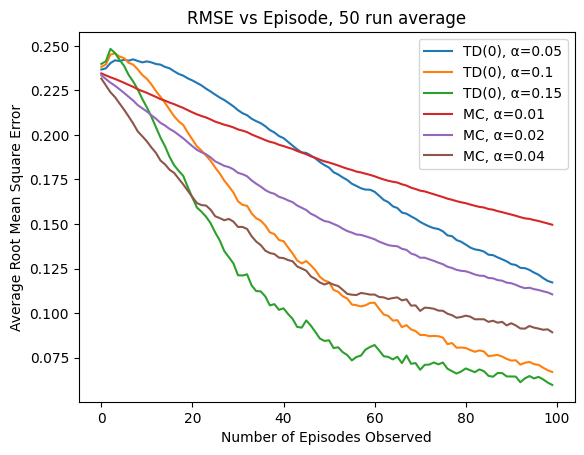

In [45]:
import matplotlib.pyplot as plt

independent_runs = 50
runs_recip = 1.0 / independent_runs
num_episodes = 100
td0_alphas = [0.05, 0.1, 0.15]
mc_alphas = [0.01, 0.02, 0.04]
labels = [f"TD(0), α={a}" for a in td0_alphas] + [f"MC, α={a}" for a in mc_alphas]

# Helper to create fresh predictors after each run
def create_predictors():
    predictors = []
    for alpha in td0_alphas:
        predictors.append(TD0Prediction(alpha))
    for alpha in mc_alphas:
        predictors.append(MCPrediction(alpha))
    return predictors

mean_error = [[0 for _ in range(num_episodes)] for _ in labels]

# Collect data
for _ in range(independent_runs):
    # Create predictors
    predictors = create_predictors()
    # Collect error data
    error = run_predictions(env, predictors, v_pi_star, num_episodes=num_episodes)
    # Update our running totals
    #mean_error = map(lambda means, samples: map(lambda mean, sample: mean + (runs_recip * sample), means, samples), mean_error, error)
    mean_error = [[mean + (runs_recip * sample)for mean, sample in zip(means, samples)] for means, samples in zip(mean_error, error)]

# Plot RMS vs Episode for our 6 methods
fig, ax = plt.subplots()
for label, errors in zip(labels, mean_error):
    ax.plot(errors, label=label)
ax.set_title("RMSE vs Episode, 50 run average")
ax.set_ylabel("Average Root Mean Square Error")
ax.set_xlabel("Number of Episodes Observed")
ax.legend()



One observation that becomes visible in this plot is that regardless of alpha, the error vs episode curve for TD(0) has a consistent shape that distinguishes it from MC - in the early episodes, MC strictly improves, whereas TD(0) starts by getting worse. This seems to be a consequence of the TD update - in part (b) of this problem, I saw V(F) actualy decreases in the first episode due to V(G)'s initial value of 0. Eventually this resolves itself pretty consistently, and after this "slow start" TD(0) seems to improve faster (sharper line / higher derivative) than MC when it's learning rate is high enough (when set to 0.05, its error reduces slower than MC with alpha >= 0.2). Overall, the initial worse prformance seems to be justified with how much faster the TD methods improve compared to their MC counterparts.

Regardless of base method being used, the predictors stop linearly increasing from episode to episode and begin "zig zagging" down towards 0 error the lower they get (seen in TD0 with alpha >= 0.1 and MC with alpha == 0.4). This common behavior indicates that the updates for both methods are likely overshooting, and would benefit from a decaying learning rate. By contrast, the other three curves stay much smoother despite having higher total error. I think this is a good case for the practice of reducing the learning rate after some fixed number of episodes that I have seen pretty frequently in literature. That way, we can obtain the benefits of both having a high alpha early in training, and a lower alpha as we get closer to convergence. 

While the TD & MC curves all share a general shape, the value of alpha does seem to have a significant impact on the shape of the MC curve. When alpha is low it looks almost linear, but when it is high it appears similar to exponential decay. This is probably closer to the "true" shape of this curve, as with a low decay constant linear decay can appear linear. This indicates that error over time for monte carlo techniques behave as exponential decay with their learning rate proportional to their decay constant. TD(0)'s curve also resembles linear decay after the point at which the error gets worse. This logically makes sense, as exponential decay is defined as the rate of change being proprotional to the value (as error decreases, it changes less). In the error term for both TD & MC, the update target will decrease as the prediction approaches V_pi_star, causing the approximations to change less and giving us this exponential behavior.